# Generator matching on two moons


Notebook for comparing drift-only and stochastic generator matching.


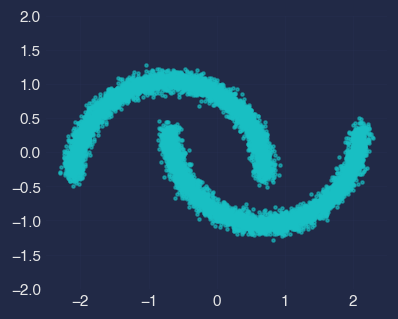

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_moons

import nami

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def ema(values, decay: float = 0.97):
    values = np.asarray(values)
    smooth = np.copy(values)
    for i in range(1, len(smooth)):
        smooth[i] = decay * smooth[i - 1] + (1.0 - decay) * values[i]
    return smooth


def panel_label(ax, text: str):
    ax.text(0.03, 0.97, text, transform=ax.transAxes, ha="left", va="top", fontsize=9)


def finish_equal(ax, *, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0)):
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)


def scatter_points(ax, points, *, s=4, alpha=0.5, color=None, label=None):
    pts = as_numpy(points)
    ax.scatter(pts[:, 0], pts[:, 1], s=s, alpha=alpha, color=color, label=label)


def plot_loss_curves(runs, *, figsize=(6, 3.5), ylabel="loss"):
    fig, ax = plt.subplots(figsize=figsize)
    for label, run in runs.items():
        ax.plot(ema(run["losses"]), label=label, lw=1.5)
    ax.set_xlabel("step")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    plt.show()


def plot_sample_grid(samples, *, reference=None, centers=None, metrics=None, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0)):
    fig, axes = plt.subplots(
        1, len(samples), figsize=(3.2 * len(samples), 3.4), sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes)
    for ax, (label, sample) in zip(axes, samples.items()):
        if reference is not None:
            scatter_points(ax, reference, s=2, alpha=0.15, color="black")
        scatter_points(ax, sample, s=4, alpha=0.5)
        if centers is not None:
            scatter_points(ax, centers, s=60, alpha=1.0, color="tab:red")
        if metrics and label in metrics:
            m = metrics[label]
            suffix = f" ED={m['ed']:.3f}"
            if "covered" in m:
                suffix += f" covered={m['covered']}"
            panel_label(ax, f"{label}{suffix}")
        else:
            panel_label(ax, label)
        finish_equal(ax, xlim=xlim, ylim=ylim)
    plt.show()


def plot_mass_bars(metrics, *, n_groups: int, xlabel: str, ylabel: str):
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 2.8), sharey=True)
    axes = np.atleast_1d(axes)
    xs = np.arange(n_groups)
    ymax = max(0.25, max(m["p"].max() for m in metrics.values()) * 1.1)
    for ax, (label, m) in zip(axes, metrics.items()):
        ax.bar(xs, m["p"], color="tab:purple")
        ax.axhline(1.0 / n_groups, color="lightgray", ls="--", lw=1, label="uniform")
        ax.set_xticks(xs)
        ax.set_xlabel(xlabel)
        ax.set_ylim(0, ymax)
        panel_label(ax, f"{label} between={m['between_mass'] * 100:.1f}%")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=7, loc="upper right")
    plt.show()


def sample_moons(n: int, noise: float = 0.05) -> torch.Tensor:
    pts, _ = make_moons(n_samples=n, noise=noise)
    pts = pts.astype(np.float32)
    pts -= pts.mean(0, keepdims=True)
    pts *= 1.4
    return torch.from_numpy(pts)


moons_preview = sample_moons(10000)
fig, ax = plt.subplots(figsize=(4, 4))
scatter_points(ax, moons_preview, s=4, alpha=0.6)
finish_equal(ax)
plt.show()


In [2]:
def make_generator(dim: int = 2, diffusion: str = "diagonal", hidden: int = 128, layers: int = 3):
    op = nami.ItoGeneratorOperator(event_shape=dim, diffusion=diffusion)
    field = nami.GeneratorField(dim=dim, operator=op, hidden=hidden, layers=layers)
    param = nami.generator_prediction(op)
    return op, field, param


def train(
    *,
    diffusion: str,
    sample_fn=sample_moons,
    interpolant=None,
    dim: int = 2,
    steps: int = 3000,
    batch: int = 2048,
    lr: float = 2e-3,
    seed: int = 0,
    log_every: int | None = None,
):
    torch.manual_seed(seed)
    op, field, param = make_generator(dim=dim, diffusion=diffusion)
    optim = torch.optim.Adam(field.parameters(), lr=lr)
    interpolant = interpolant or nami.BrownianBridgeInterpolant()

    losses: list[float] = []
    for step in range(steps):
        x_noise = torch.randn(batch, dim)
        x_data = sample_fn(batch)
        loss = nami.regression_loss(
            field,
            x_noise=x_noise,
            x_data=x_data,
            interpolant=interpolant,
            parameterization=param,
            eps_t=1e-3,
        )
        optim.zero_grad()
        loss.backward()
        optim.step()
        losses.append(loss.item())
        if log_every and (step % log_every == 0 or step == steps - 1):
            print(f"step {step:5d}  loss {loss.item():.4f}")
    return {"op": op, "field": field, "param": param, "losses": losses, "dim": dim}


In [3]:
TRAIN_STEPS = 8000
TRAIN_BATCH = 1024

runs = {
    "ODE": train(diffusion="none", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0),
    "SDE": train(diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0),
}


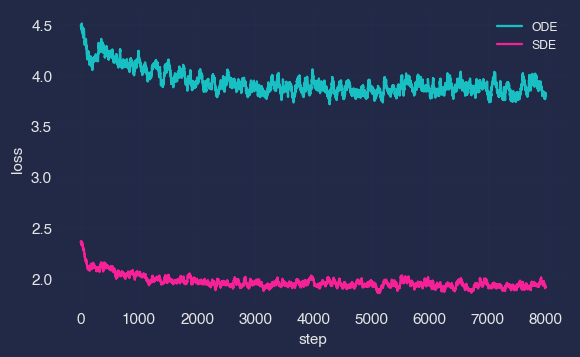

In [4]:
plot_loss_curves(runs)


In [5]:
def make_process(run, *, steps: int):
    op, field, param = run["op"], run["field"], run["param"]
    solver = nami.EulerMaruyama(steps=steps) if op.diffusion_mode != "none" else nami.RK4(steps=steps)
    return nami.GeneratorMatching(
        field,
        solver,
        parameterization=param,
        base=nami.StandardNormal(run.get("dim", 2)),
    )()


@torch.no_grad()
def sample_from(run, *, n: int, steps: int = 100, seed: int = 1) -> torch.Tensor:
    torch.manual_seed(seed)
    return make_process(run, steps=steps).sample((n,))


@torch.no_grad()
def record_trajectory(run, *, n: int, steps: int = 100, seed: int = 2):
    torch.manual_seed(seed)
    op, field = run["op"], run["field"]
    x = torch.randn(n, run.get("dim", 2))
    dt = 1.0 / steps
    path = [x.clone()]
    t = 0.0
    is_sde = op.diffusion_mode != "none"

    for _ in range(steps):
        t_tensor = torch.full((n,), t)
        params = op.project(field(x, t_tensor))
        drift = op.drift(x, t_tensor, params)
        if is_sde:
            g = op.diffusion(x, t_tensor, params)
            x = x + drift * dt + g * math.sqrt(dt) * torch.randn_like(x)
        else:
            x = x + drift * dt
        t += dt
        path.append(x.clone())
    return torch.stack(path, dim=0)


samples = {label: sample_from(run, n=2000, steps=100) for label, run in runs.items()}
data_ref = sample_moons(10000)


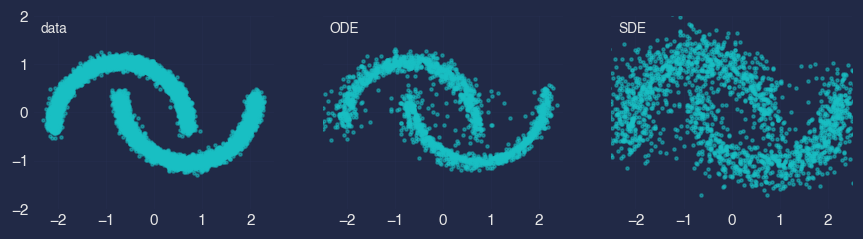

In [6]:
plot_sample_grid({"data": data_ref, **samples}, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0))

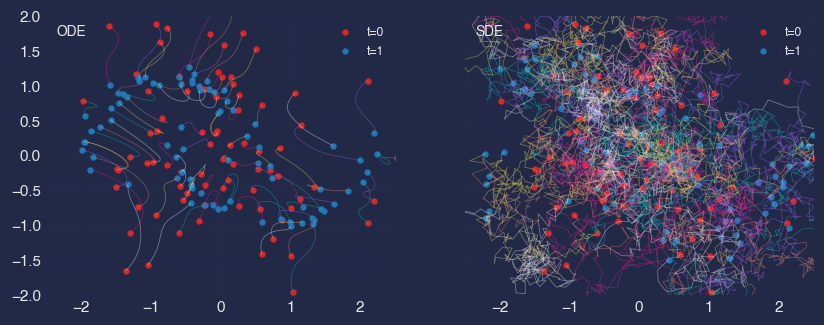

In [7]:
fig, axes = plt.subplots(1, len(runs), figsize=(4.5 * len(runs), 4.5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, run) in zip(axes, runs.items()):
    path = as_numpy(record_trajectory(run, n=80, steps=100, seed=2))
    for i in range(path.shape[1]):
        ax.plot(path[:, i, 0], path[:, i, 1], lw=0.5, alpha=0.4)
    ax.scatter(path[0, :, 0], path[0, :, 1], s=10, color="tab:red", label="t=0")
    ax.scatter(path[-1, :, 0], path[-1, :, 1], s=10, color="tab:blue", label="t=1")
    panel_label(ax, label)
    finish_equal(ax)
    ax.legend(loc="upper right", fontsize=8)
plt.show()


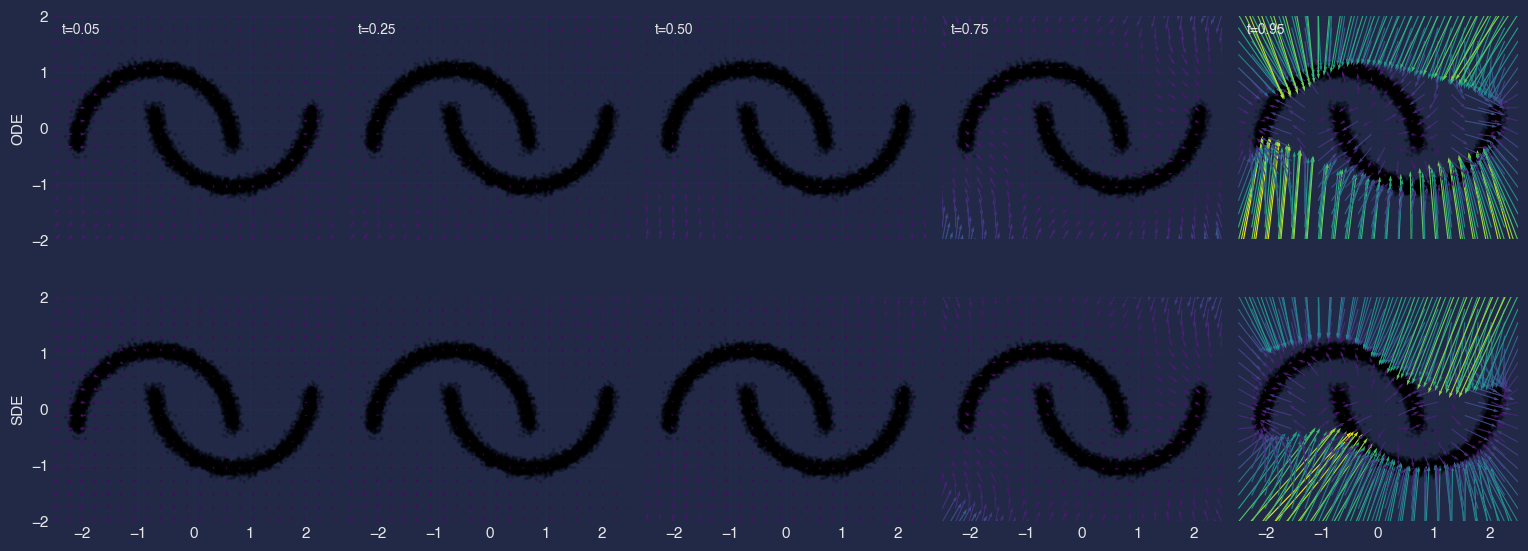

In [8]:
@torch.no_grad()
def drift_grid(run, t: float, lim: float = 2.5, n: int = 22):
    op, field = run["op"], run["field"]
    xs = torch.linspace(-lim, lim, n)
    ys = torch.linspace(-lim, lim, n)
    gx, gy = torch.meshgrid(xs, ys, indexing="xy")
    pts = torch.stack([gx.flatten(), gy.flatten()], dim=-1)
    t_tensor = torch.full((pts.shape[0],), t)
    params = op.project(field(pts, t_tensor))
    drift = op.drift(pts, t_tensor, params).reshape(n, n, 2)
    return as_numpy(gx), as_numpy(gy), as_numpy(drift)


t_grid = [0.05, 0.25, 0.5, 0.75, 0.95]
fig, axes = plt.subplots(
    len(runs), len(t_grid),
    figsize=(2.8 * len(t_grid), 2.8 * len(runs)),
    sharex=True, sharey=True,
)
for row, (label, run) in enumerate(runs.items()):
    grids = [drift_grid(run, t=t) for t in t_grid]
    speeds = [np.linalg.norm(dr, axis=-1) for _, _, dr in grids]
    vmax = float(np.max([s.max() for s in speeds]))

    for col, (t, (gx, gy, dr), speed) in enumerate(zip(t_grid, grids, speeds)):
        ax = axes[row, col]
        scatter_points(ax, data_ref, s=2, alpha=0.15, color="black")
        ax.quiver(
            gx, gy, dr[..., 0], dr[..., 1], speed,
            cmap="viridis", scale=50, width=0.004, clim=(0, vmax),
        )
        finish_equal(ax)
        if row == 0:
            panel_label(ax, f"t={t:.2f}")
        if col == 0:
            ax.set_ylabel(label)
fig.tight_layout()
plt.show()


In [9]:
@torch.no_grad()
def energy_distance(x: torch.Tensor, y: torch.Tensor) -> float:
    def mean_pairwise(a, b):
        return torch.cdist(a, b).mean().item()

    return 2 * mean_pairwise(x, y) - mean_pairwise(x, x) - mean_pairwise(y, y)


def sample_pair(sample_fn, *, n: int = 4000, seeds=(42, 43)):
    torch.manual_seed(seeds[0])
    a = sample_fn(n)
    torch.manual_seed(seeds[1])
    b = sample_fn(n)
    return a, b


def evaluate_runs(run_dict, eval_data, *, stats_fn=None, n: int = 4000, steps: int = 100, seed: int = 7):
    samples = {}
    metrics = {}
    for label, run in run_dict.items():
        sample = sample_from(run, n=n, steps=steps, seed=seed)
        samples[label] = sample
        metric = {"ed": energy_distance(sample, eval_data)}
        if stats_fn is not None:
            metric.update(stats_fn(sample))
        metrics[label] = metric
    return samples, metrics


def print_metric_table(metrics, *, baseline=None, count_name="modes"):
    has_counts = any("covered" in m for m in metrics.values()) or (
        baseline is not None and "covered" in baseline
    )
    if has_counts:
        print(f"{'run':32s} | {'ED':>7s} | {count_name:>6s} | {'KL':>8s} | {'between':>8s}")
        if baseline is not None:
            print(f"{'data baseline':32s} | {baseline['ed']:>7.4f} | {baseline['covered']:>6d} | "
                  f"{baseline['kl']:>8.4f} | {baseline['between_mass']:>8.3f}")
        for label, m in metrics.items():
            print(f"{label:32s} | {m['ed']:>7.4f} | {m['covered']:>6d} | "
                  f"{m['kl']:>8.4f} | {m['between_mass']:>8.3f}")
    else:
        print(f"{'run':32s} | {'ED':>7s}")
        if baseline is not None:
            print(f"{'data baseline':32s} | {baseline['ed']:>7.4f}")
        for label, m in metrics.items():
            print(f"{label:32s} | {m['ed']:>7.4f}")


data_eval, data_eval_b = sample_pair(sample_moons)
baseline = energy_distance(data_eval, data_eval_b)
_, moons_metrics = evaluate_runs(runs, data_eval, n=4000, steps=200, seed=7)
print_metric_table(moons_metrics, baseline={"ed": baseline})


run                              |      ED
data baseline                    |  0.0001
ODE                              |  0.0020
SDE                              |  0.0297


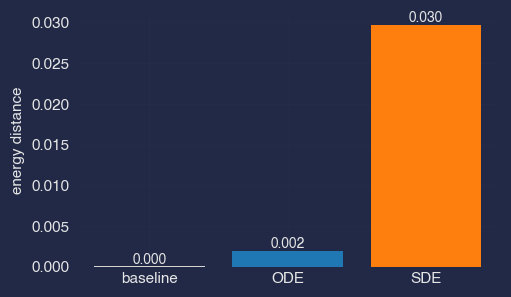

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))
labels = ["baseline"] + list(moons_metrics.keys())
values = [baseline] + [m["ed"] for m in moons_metrics.values()]
bars = ax.bar(labels, values, color=["lightgray", "tab:blue", "tab:orange"])
ax.set_ylabel("energy distance")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.show()

## Why is the SDE worse here?

Two quick checks separate solver error from model error. First, refine the solver step count and compare the SDE curve with a `sqrt(dt)` reference. Second, stop the SDE at `t=0.95` and finish with a short deterministic RK4 tail.

The sweep is mostly flat for the SDE, so discretisation is not the main problem. The RK4 tail helps a bit, but it does not close the gap. With a constant diagonal diffusion target, the model can learn a drift and diffusion pair whose terminal marginal is biased for this near-1D target. Reducing `dt` cannot remove that bias; a diffusion schedule has to be part of training.


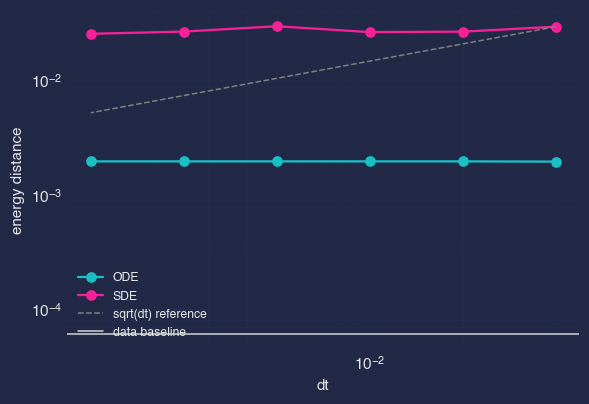

energy distance vs dt:
   steps |            ODE |            SDE
      25 |         0.0019 |         0.0295
      50 |         0.0020 |         0.0267
     100 |         0.0020 |         0.0264
     200 |         0.0020 |         0.0297
     400 |         0.0020 |         0.0267
     800 |         0.0020 |         0.0255


In [11]:
step_grid = [25, 50, 100, 200, 400, 800]
sweep = {label: [] for label in runs}
for steps in step_grid:
    for label, run in runs.items():
        s = sample_from(run, n=4000, steps=steps, seed=7)
        sweep[label].append(energy_distance(s, data_eval))

dts = np.array([1.0 / s for s in step_grid])

fig, ax = plt.subplots(figsize=(6, 4))
for label, vals in sweep.items():
    ax.loglog(dts, vals, marker="o", label=label, lw=1.5)

sde_vals = np.array(sweep["SDE"])
ref = sde_vals[0] * np.sqrt(dts / dts[0])
ax.loglog(dts, ref, "--", color="gray", lw=1, label="sqrt(dt) reference")
ax.axhline(baseline, color="lightgray", lw=1, label="data baseline")
ax.set_xlabel("dt")
ax.set_ylabel("energy distance")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.25)
plt.show()

print("energy distance vs dt:")
print(f"  {'steps':>6} | " + " | ".join(f"{lab[:14]:>14s}" for lab in sweep))
for i, s in enumerate(step_grid):
    cells = " | ".join(f"{sweep[lab][i]:>14.4f}" for lab in sweep)
    print(f"  {s:>6d} | {cells}")


baseline     : 0.0001
ODE          : 0.0020
SDE          : 0.0264
SDE at 0.95  : 0.0356
polished SDE : 0.0229


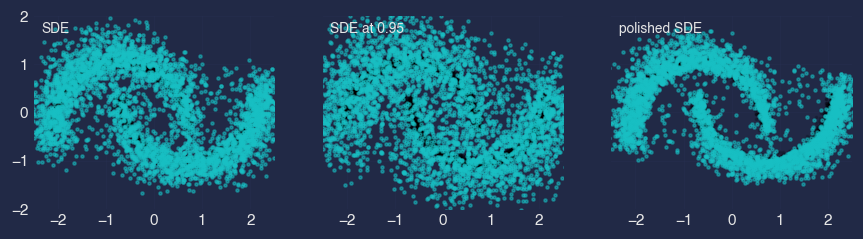

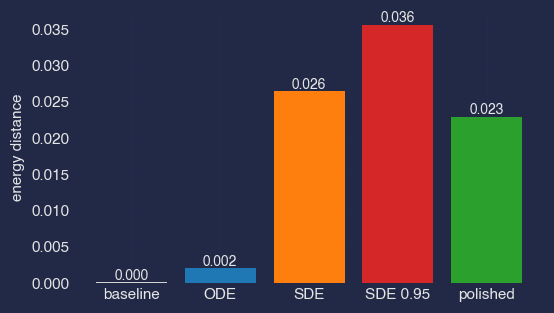

In [12]:
from nami.processes.gm import cast_time


def model_dynamics(run, *, diffusion_scale=None):
    op, field = run["op"], run["field"]

    def drift(x, t):
        tt = cast_time(t, x)
        params = op.project(field(x, tt))
        return op.drift(x, tt, params)

    def diffusion(x, t):
        tt = cast_time(t, x)
        params = op.project(field(x, tt))
        g = op.diffusion(x, tt, params)
        if diffusion_scale is not None:
            g = g * diffusion_scale(float(t))
        return g

    return drift, diffusion


@torch.no_grad()
def polished_sample(
    sde_run, *, n: int, t_switch: float = 0.95,
    sde_steps: int = 95, ode_steps: int = 5, seed: int = 7,
):
    torch.manual_seed(seed)
    drift, diffusion = model_dynamics(sde_run)
    x0 = torch.randn(n, 2)
    x_mid = nami.EulerMaruyama(steps=sde_steps).integrate(
        drift, diffusion, x0, t0=0.0, t1=t_switch, steps=sde_steps,
    )
    x_end = nami.RK4(steps=ode_steps).integrate(
        drift, x_mid, t0=t_switch, t1=1.0, steps=ode_steps,
    )
    return x_mid, x_end


sde_run = runs["SDE"]
x_mid, x_polished = polished_sample(sde_run, n=4000, t_switch=0.95, sde_steps=95, ode_steps=5, seed=7)
x_sde_vanilla = sample_from(sde_run, n=4000, steps=100, seed=7)
x_ode_vanilla = sample_from(runs["ODE"], n=4000, steps=100, seed=7)

ed_vanilla_sde = energy_distance(x_sde_vanilla, data_eval)
ed_polished = energy_distance(x_polished, data_eval)
ed_vanilla_ode = energy_distance(x_ode_vanilla, data_eval)
ed_mid = energy_distance(x_mid, data_eval)

print(f"baseline     : {baseline:.4f}")
print(f"ODE          : {ed_vanilla_ode:.4f}")
print(f"SDE          : {ed_vanilla_sde:.4f}")
print(f"SDE at 0.95  : {ed_mid:.4f}")
print(f"polished SDE : {ed_polished:.4f}")

plot_sample_grid(
    {"SDE": x_sde_vanilla, "SDE at 0.95": x_mid, "polished SDE": x_polished},
    reference=data_eval,
    xlim=(-2.5, 2.5),
    ylim=(-2.0, 2.0),
)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
labels = ["baseline", "ODE", "SDE", "SDE 0.95", "polished"]
values = [baseline, ed_vanilla_ode, ed_vanilla_sde, ed_mid, ed_polished]
colors = ["lightgray", "tab:blue", "tab:orange", "tab:red", "tab:green"]
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("energy distance")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.show()


### Sampling-time diffusion taper

Before changing training, keep the SDE field fixed and taper only the sampled diffusion with `sigma(t) = (1 - t)^p`. This isolates terminal noise from the learned drift-diffusion bias. If terminal noise dominates, large `p` should close most of the gap.


  p=0.0            : 0.0264
  p=0.5            : 0.0137
  p=1.0            : 0.0107
  p=2.0            : 0.0090
  p=4.0            : 0.0071
  p=8.0            : 0.0059
  ODE limit        : 0.0045

vanilla ODE: 0.0020


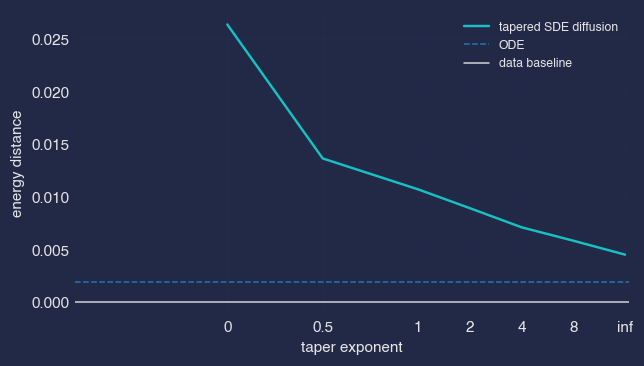

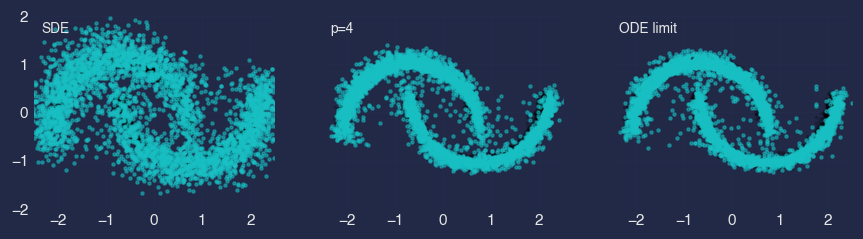

In [13]:
@torch.no_grad()
def tapered_sample(sde_run, *, n: int, p: float, steps: int = 100, seed: int = 7):
    torch.manual_seed(seed)
    drift, diffusion = model_dynamics(
        sde_run,
        diffusion_scale=lambda t: max(0.0, 1.0 - t) ** p,
    )
    x0 = torch.randn(n, 2)
    if math.isinf(p):
        return nami.RK4(steps=steps).integrate(drift, x0, t0=0.0, t1=1.0, steps=steps)
    return nami.EulerMaruyama(steps=steps).integrate(
        drift, diffusion, x0, t0=0.0, t1=1.0, steps=steps,
    )


p_grid = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0, math.inf]
taper_metrics = []
taper_samples = {}
for p in p_grid:
    s = tapered_sample(sde_run, n=4000, p=p, steps=100, seed=7)
    ed = energy_distance(s, data_eval)
    taper_metrics.append(ed)
    taper_samples[p] = s
    label = f"p={p}" if not math.isinf(p) else "ODE limit"
    print(f"  {label:16s} : {ed:.4f}")

print()
print(f"vanilla ODE: {ed_vanilla_ode:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
xs = [p if not math.isinf(p) else p_grid[-2] * 2 for p in p_grid]
ax.plot(xs, taper_metrics, lw=1.6, label="tapered SDE diffusion")
ax.axhline(ed_vanilla_ode, color="tab:blue", ls="--", lw=1, label="ODE")
ax.axhline(baseline, color="lightgray", lw=1, label="data baseline")
ax.set_xscale("symlog", linthresh=1.0)
ax.set_xticks(xs)
ax.set_xticklabels([f"{p:g}" if not math.isinf(p) else "inf" for p in p_grid])
ax.set_xlabel("taper exponent")
ax.set_ylabel("energy distance")
ax.legend(fontsize=8)
plt.show()

plot_sample_grid(
    {"SDE": taper_samples[0.0], "p=4": taper_samples[4.0], "ODE limit": taper_samples[math.inf]},
    reference=data_eval,
    xlim=(-2.5, 2.5),
    ylim=(-2.0, 2.0),
)


### What does GM scheduling buy?

Sampling-time tapering removes most of the SDE-to-ODE gap, but a small residual remains because the SDE drift was trained against a constant diffusion target.

The next experiment trains the schedule directly. `TaperedBridgeInterpolant` keeps the same bridge path but asks the model to emit a diffusion target `sigma_max * (1 - t)^p`. We sweep `sigma_max`, then run a small solver-step sweep to see whether stochasticity helps at low step counts.


In [14]:
from dataclasses import dataclass

from nami.interpolants._common import broadcast_t as _broadcast_t
from nami.interpolants.protocol import InterpolantState
from nami.parameterizations import (
    Action, Epsilon, GeneratorParams, Score, Velocity, VPrediction, X0,
)


@dataclass(frozen=True)
class TaperedBridgeInterpolant:
    """Brownian bridge with a time-varying target diffusion."""

    sigma_max: float = 1.0
    p: float = 2.0
    eps: float = 1e-5

    def __post_init__(self):
        if self.sigma_max < 0:
            raise ValueError("sigma_max must be non-negative")
        if self.p < 0:
            raise ValueError("p must be non-negative")
        if not (0 < self.eps < 0.5):
            raise ValueError("eps must be in (0, 0.5)")

    def sample(self, x_noise, x_data, t, *, noise=None):
        tt = _broadcast_t(t, x_data)
        mu = (1.0 - tt) * x_noise + tt * x_data
        if noise is None:
            noise = torch.randn_like(mu)
        std = self.sigma_max * torch.sqrt(tt * (1.0 - tt))
        xt = mu + std * noise
        return InterpolantState(xt=xt, x_data=x_data, x_noise=x_noise, t=t, noise=noise)

    def target(self, target, state):
        match target:
            case Velocity():
                return self._velocity(state)
            case Score():
                return self._score(state)
            case GeneratorParams(operator=op):
                drift = self._velocity(state)
                if getattr(op, "diffusion_mode", "none") == "none":
                    return op.pack_params(drift=drift)
                tt = _broadcast_t(state.t, state.x_data)
                sigma_t = self.sigma_max * (1.0 - tt).clamp(min=0.0) ** self.p
                diffusion = sigma_t.expand_as(state.x_data).clone()
                return op.pack_params(drift=drift, diffusion=diffusion)
            case Action():
                return self._velocity(state)
            case Epsilon() | X0() | VPrediction():
                raise NotImplementedError(
                    f"TaperedBridgeInterpolant does not support {type(target).__name__}"
                )

    def _velocity(self, state):
        x_noise, x_data = state.x_noise, state.x_data
        tt = _broadcast_t(state.t, x_data)
        mu = (1.0 - tt) * x_noise + tt * x_data
        denom = 2.0 * torch.clamp(tt * (1.0 - tt), min=self.eps)
        coeff = (1.0 - 2.0 * tt) / denom
        return (x_data - x_noise) + coeff * (state.xt - mu)

    def _score(self, state):
        x_noise, x_data = state.x_noise, state.x_data
        tt = _broadcast_t(state.t, x_data)
        mu = (1.0 - tt) * x_noise + tt * x_data
        var = self.sigma_max ** 2 * torch.clamp(tt * (1.0 - tt), min=self.eps)
        return (mu - state.xt) / var


_op = nami.ItoGeneratorOperator(event_shape=2, diffusion="diagonal")
_interp = TaperedBridgeInterpolant(sigma_max=1.0, p=2.0)
_state = _interp.sample(torch.randn(4, 2), torch.randn(4, 2), torch.tensor([0.0, 0.3, 0.7, 0.99]))
_tgt = _interp.target(nami.GeneratorParams(operator=_op), _state)

print("target diffusion at t = [0.00, 0.30, 0.70, 0.99]:")
print(_tgt[:, 1, :].numpy().round(4))


target diffusion at t = [0.00, 0.30, 0.70, 0.99]:
[[1.0e+00 1.0e+00]
 [4.9e-01 4.9e-01]
 [9.0e-02 9.0e-02]
 [1.0e-04 1.0e-04]]


training tapered SDE sigma_max=0.3 p=2 ...
training tapered SDE sigma_max=1 p=2 ...
training tapered SDE sigma_max=3 p=2 ...


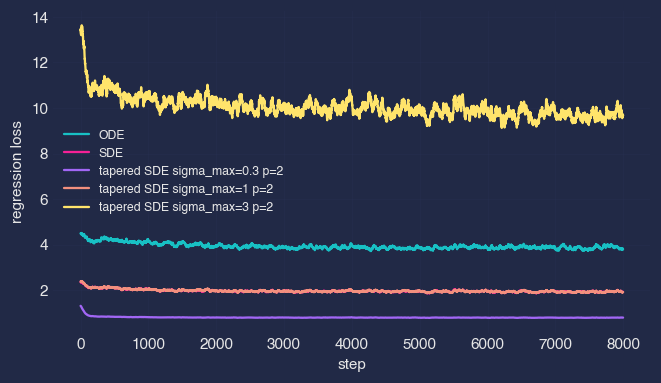


run                              |      ED
data baseline                    |  0.0001
ODE                              |  0.0020
SDE                              |  0.0264
tapered SDE sigma_max=0.3 p=2    |  0.0023
tapered SDE sigma_max=1 p=2      |  0.0050
tapered SDE sigma_max=3 p=2      |  0.0964


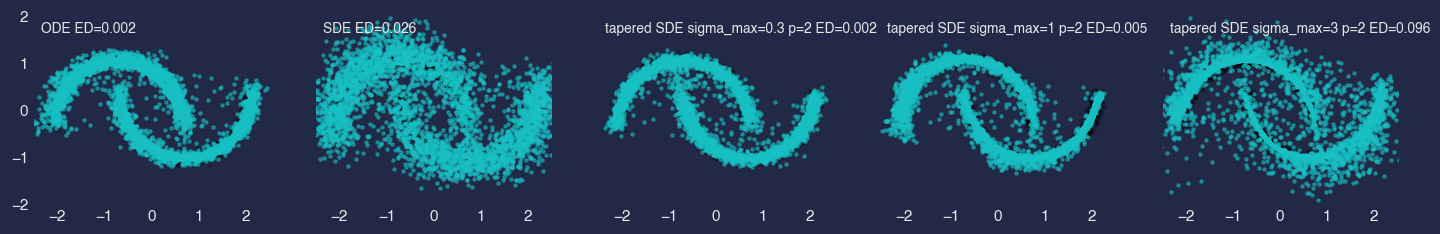

In [15]:
def tapered_label(sigma_max: float, p: float = 2.0):
    return f"tapered SDE sigma_max={sigma_max:g} p={p:g}"


sigma_grid = [0.3, 1.0, 3.0]
tapered_runs = {}
for sigma_max in sigma_grid:
    label = tapered_label(sigma_max)
    print(f"training {label} ...")
    tapered_runs[label] = train(
        interpolant=TaperedBridgeInterpolant(sigma_max=sigma_max, p=2.0),
        diffusion="diagonal",
        steps=TRAIN_STEPS,
        batch=TRAIN_BATCH,
        seed=0,
    )

all_runs = {"ODE": runs["ODE"], "SDE": runs["SDE"], **tapered_runs}
plot_loss_curves(all_runs, figsize=(7, 3.8), ylabel="regression loss")

sample_cache, ed_metrics = evaluate_runs(all_runs, data_eval, n=4000, steps=100, seed=7)
print()
print_metric_table(ed_metrics, baseline={"ed": baseline})

ed_results = {label: m["ed"] for label, m in ed_metrics.items()}
plot_sample_grid(sample_cache, reference=data_eval, metrics=ed_metrics, xlim=(-2.5, 2.5), ylim=(-2.0, 2.0))


best tapered SDE: tapered SDE sigma_max=0.3 p=2  ED=0.0023


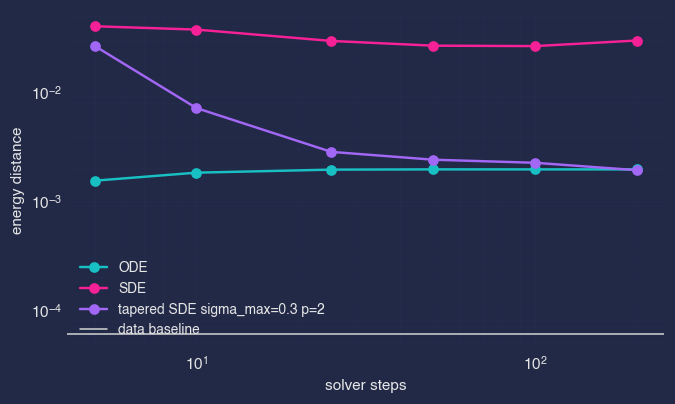


energy distance vs solver steps:
   steps |                    ODE |                    SDE | tapered SDE sigma_max=
       5 |                 0.0015 |                 0.0402 |                 0.0265
      10 |                 0.0018 |                 0.0374 |                 0.0071
      25 |                 0.0019 |                 0.0295 |                 0.0028
      50 |                 0.0020 |                 0.0267 |                 0.0024
     100 |                 0.0020 |                 0.0264 |                 0.0023
     200 |                 0.0020 |                 0.0297 |                 0.0019


In [16]:
best_tapered_label = min(tapered_runs, key=lambda k: ed_results[k])
best_tapered = tapered_runs[best_tapered_label]
print(f"best tapered SDE: {best_tapered_label}  ED={ed_results[best_tapered_label]:.4f}")

step_grid = [5, 10, 25, 50, 100, 200]
sweep_runs = {
    "ODE": runs["ODE"],
    "SDE": runs["SDE"],
    best_tapered_label: best_tapered,
}

sweep_metrics = {label: [] for label in sweep_runs}
for steps in step_grid:
    for label, run in sweep_runs.items():
        s = sample_from(run, n=4000, steps=steps, seed=7)
        sweep_metrics[label].append(energy_distance(s, data_eval))

fig, ax = plt.subplots(figsize=(7, 4))
for label, vals in sweep_metrics.items():
    ax.loglog(step_grid, vals, marker="o", lw=1.6, label=label)
ax.axhline(baseline, color="lightgray", lw=1, label="data baseline")
ax.set_xlabel("solver steps")
ax.set_ylabel("energy distance")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.25)
plt.show()

print()
print("energy distance vs solver steps:")
print(f"  {'steps':>6} | " + " | ".join(f"{lab[:22]:>22s}" for lab in sweep_runs))
for i, s in enumerate(step_grid):
    cells = " | ".join(f"{sweep_metrics[lab][i]:>22.4f}" for lab in sweep_runs)
    print(f"  {s:>6d} | {cells}")


## A multimodal test

Moons are connected enough that mode dropping is hard to measure. A ring of eight separated Gaussians is a cleaner test: each sample is either close to a mode or between modes.

We track energy distance, mode coverage, per-mode mass, and KL to the uniform mode distribution. The question is whether scheduled SDE noise improves coverage even when energy distance is close.


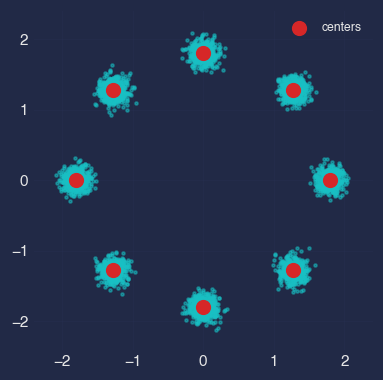

In [17]:
N_MODES = 8
RING_RADIUS = 1.8
MODE_STD = 0.1

angles_modes = torch.tensor(
    [2 * math.pi * k / N_MODES for k in range(N_MODES)], dtype=torch.float32
)
mode_centers = torch.stack(
    [RING_RADIUS * torch.cos(angles_modes), RING_RADIUS * torch.sin(angles_modes)],
    dim=-1,
)


def sample_ring(n: int) -> torch.Tensor:
    idx = torch.randint(0, N_MODES, (n,))
    return mode_centers[idx] + MODE_STD * torch.randn(n, 2)


def mode_stats(samples: torch.Tensor, threshold: float = 0.4):
    dists = torch.cdist(samples, mode_centers)
    nearest_d, nearest_i = dists.min(dim=-1)
    gap = 2 * RING_RADIUS * math.sin(math.pi / N_MODES)
    assigned = nearest_d < threshold * gap / 2
    counts = torch.bincount(nearest_i[assigned], minlength=N_MODES).float()
    p = counts / max(counts.sum().item(), 1.0)
    uniform = torch.full_like(p, 1.0 / N_MODES)
    eps = 1e-12
    return {
        "p": p.numpy(),
        "covered": int((p > 0.01).sum().item()),
        "kl": float((p * (p.clamp(min=eps).log() - uniform.log())).sum().item()),
        "between_mass": float(1.0 - assigned.float().mean().item()),
    }


preview_ring = sample_ring(4000)
fig, ax = plt.subplots(figsize=(4, 4))
scatter_points(ax, preview_ring, s=4, alpha=0.5)
scatter_points(ax, mode_centers, s=80, alpha=1.0, color="tab:red", label="centers")
finish_equal(ax, xlim=(-2.4, 2.4), ylim=(-2.4, 2.4))
ax.legend(fontsize=8)
plt.show()


In [18]:
print("training on 8-Gaussian ring ...")
ring_runs = {
    "ODE": train(
        sample_fn=sample_ring, interpolant=nami.LinearInterpolant(), diffusion="none",
        steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
    "SDE": train(
        sample_fn=sample_ring, interpolant=nami.BrownianBridgeInterpolant(sigma=1.0),
        diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
    "tapered SDE 0.3": train(
        sample_fn=sample_ring, interpolant=TaperedBridgeInterpolant(sigma_max=0.3, p=2.0),
        diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
    "tapered SDE 1.0": train(
        sample_fn=sample_ring, interpolant=TaperedBridgeInterpolant(sigma_max=1.0, p=2.0),
        diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
}

ring_eval, ring_eval_b = sample_pair(sample_ring, seeds=(123, 124))
ring_baseline = {"ed": energy_distance(ring_eval, ring_eval_b), **mode_stats(ring_eval)}
ring_samples, ring_metrics = evaluate_runs(ring_runs, ring_eval, stats_fn=mode_stats, n=4000, steps=100, seed=7)

print()
print_metric_table(ring_metrics, baseline=ring_baseline, count_name="modes")


training on 8-Gaussian ring ...

run                              |      ED |  modes |       KL |  between
data baseline                    |  0.0003 |      8 |   0.0006 |    0.021
ODE                              |  0.0024 |      8 |   0.0037 |    0.050
SDE                              |  0.0165 |      8 |   0.0114 |    0.606
tapered SDE 0.3                  |  0.0038 |      8 |   0.0023 |    0.087
tapered SDE 1.0                  |  0.0079 |      8 |   0.0046 |    0.168


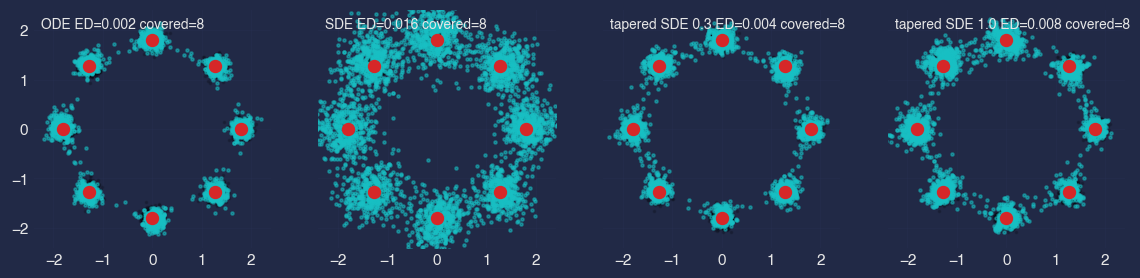

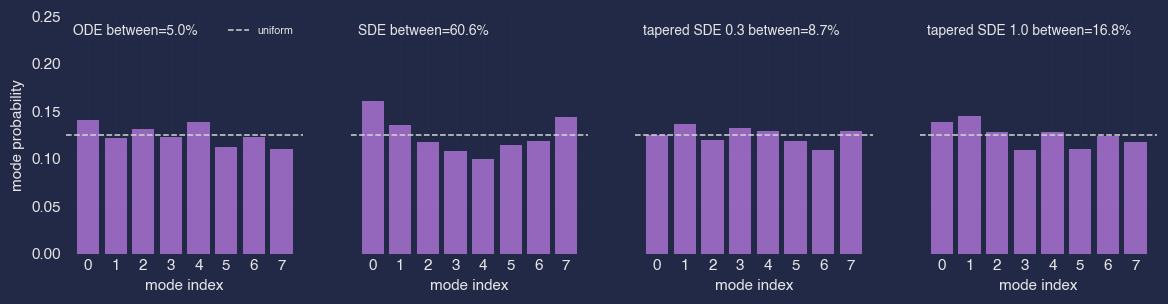

In [19]:
plot_sample_grid(
    ring_samples,
    reference=ring_eval,
    centers=mode_centers,
    metrics=ring_metrics,
    xlim=(-2.4, 2.4),
    ylim=(-2.4, 2.4),
)
plot_mass_bars(ring_metrics, n_groups=N_MODES, xlabel="mode index", ylabel="mode probability")


### Sweep the taper exponent

The ring sweep favored `sigma_max=0.3`. Now keep that fixed and vary the exponent `p`, which controls how quickly the target diffusion decays near the endpoint.


training tapered SDE sigma_max=0.3 p=0.5 ...
training tapered SDE sigma_max=0.3 p=1 ...
training tapered SDE sigma_max=0.3 p=2 ...
training tapered SDE sigma_max=0.3 p=4 ...
training tapered SDE sigma_max=0.3 p=8 ...

run                              |      ED |  modes |       KL |  between
p=0.5                            |  0.0035 |      8 |   0.0034 |    0.093
p=1                              |  0.0035 |      8 |   0.0035 |    0.081
p=2                              |  0.0038 |      8 |   0.0023 |    0.087
p=4                              |  0.0030 |      8 |   0.0015 |    0.078
p=8                              |  0.0036 |      8 |   0.0021 |    0.080


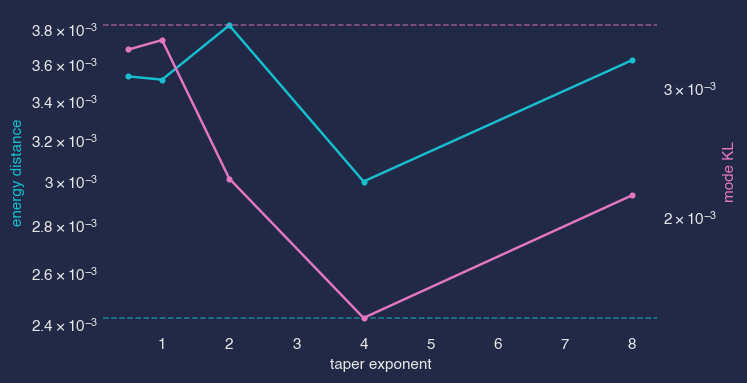

In [20]:
p_sweep_grid = [0.5, 1.0, 2.0, 4.0, 8.0]
p_sweep_runs = {}
for p in p_sweep_grid:
    label = f"p={p:g}"
    print(f"training tapered SDE sigma_max=0.3 {label} ...")
    p_sweep_runs[label] = train(
        sample_fn=sample_ring,
        interpolant=TaperedBridgeInterpolant(sigma_max=0.3, p=p),
        diffusion="diagonal",
        steps=TRAIN_STEPS,
        batch=TRAIN_BATCH,
        seed=0,
    )

p_sweep_samples, p_sweep_metrics = evaluate_runs(
    p_sweep_runs, ring_eval, stats_fn=mode_stats, n=4000, steps=100, seed=7
)

print()
print_metric_table(p_sweep_metrics, count_name="modes")

ps = [float(k.split("=")[1]) for k in p_sweep_runs]
eds = [p_sweep_metrics[k]["ed"] for k in p_sweep_runs]
kls = [p_sweep_metrics[k]["kl"] for k in p_sweep_runs]

fig, ax1 = plt.subplots(figsize=(6.5, 3.8))
ax1.semilogy(ps, eds, marker=".", color="tab:cyan", lw=1.6, label="energy distance")
ax1.set_xlabel("taper exponent")
ax1.set_ylabel("energy distance", color="tab:cyan")
ax1.tick_params(axis="y", labelcolor="tab:cyan")

ax2 = ax1.twinx()
ax2.semilogy(ps, kls, marker=".", color="tab:pink", lw=1.6, label="mode KL")
ax2.set_ylabel("mode KL", color="tab:pink")
ax2.tick_params(axis="y", labelcolor="tab:pink")
ax2.grid(False)

ax1.axhline(ring_metrics["ODE"]["ed"], color="tab:cyan", ls="--", lw=1, alpha=0.6)
ax2.axhline(ring_metrics["ODE"]["kl"], color="tab:pink", ls="--", lw=1, alpha=0.6)
plt.show()


### Pinwheel

The ring is geometrically easy: isotropic modes, equal mass, and equal spacing. The pinwheel adds curved, anisotropic arms. This is a better test of whether the diffusion target helps beyond a simple mixture.


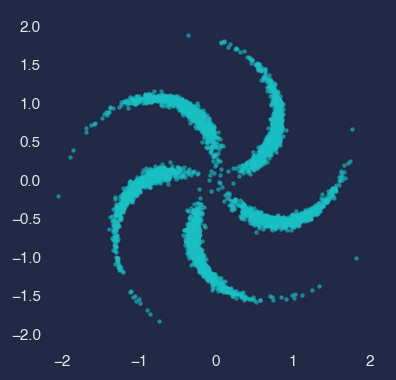

In [21]:
N_ARMS = 5
RADIAL_STD = 0.3
TANGENTIAL_STD = 0.05
SWIRL_RATE = 0.25
ARM_RADIUS = 1.0
arm_rads = torch.tensor([2 * math.pi * k / N_ARMS for k in range(N_ARMS)])


def sample_pinwheel(n: int) -> torch.Tensor:
    labels = torch.randint(0, N_ARMS, (n,))
    feats = torch.randn(n, 2)
    feats[:, 0] = feats[:, 0] * RADIAL_STD + ARM_RADIUS
    feats[:, 1] = feats[:, 1] * TANGENTIAL_STD
    twist = torch.exp(feats[:, 0]) * SWIRL_RATE
    angles = arm_rads[labels] + twist
    cos_a, sin_a = torch.cos(angles), torch.sin(angles)
    x = feats[:, 0] * cos_a - feats[:, 1] * sin_a
    y = feats[:, 0] * sin_a + feats[:, 1] * cos_a
    return torch.stack([x, y], dim=-1)


def assign_arm_with_ref(samples, ref_pts, ref_labels):
    d = torch.cdist(samples, ref_pts)
    nearest = d.argmin(dim=-1)
    return ref_labels[nearest], d.gather(-1, nearest.unsqueeze(-1)).squeeze(-1)


torch.manual_seed(99)
_ref_n = 20000
_arm_ref_labels = torch.randint(0, N_ARMS, (_ref_n,))
_feats = torch.randn(_ref_n, 2)
_feats[:, 0] = _feats[:, 0] * RADIAL_STD + ARM_RADIUS
_feats[:, 1] = _feats[:, 1] * TANGENTIAL_STD
_twist = torch.exp(_feats[:, 0]) * SWIRL_RATE
_ang = arm_rads[_arm_ref_labels] + _twist
_arm_ref_pts = torch.stack(
    [
        _feats[:, 0] * torch.cos(_ang) - _feats[:, 1] * torch.sin(_ang),
        _feats[:, 0] * torch.sin(_ang) + _feats[:, 1] * torch.cos(_ang),
    ],
    dim=-1,
)


def pinwheel_stats(samples: torch.Tensor, dist_cutoff: float = 0.4):
    labels, d = assign_arm_with_ref(samples, _arm_ref_pts, _arm_ref_labels)
    on_arm = d < dist_cutoff
    counts = torch.bincount(labels[on_arm], minlength=N_ARMS).float()
    p = counts / max(counts.sum().item(), 1.0)
    uniform = torch.full_like(p, 1.0 / N_ARMS)
    eps = 1e-12
    return {
        "p": p.numpy(),
        "covered": int((p > 0.01).sum().item()),
        "kl": float((p * (p.clamp(min=eps).log() - uniform.log())).sum().item()),
        "between_mass": float(1.0 - on_arm.float().mean().item()),
    }


preview_pinwheel = sample_pinwheel(4000)
fig, ax = plt.subplots(figsize=(4, 4))
scatter_points(ax, preview_pinwheel, s=4, alpha=0.5)
finish_equal(ax, xlim=(-2.2, 2.2), ylim=(-2.2, 2.2))
plt.show()


training on pinwheel ...

run                              |      ED |   arms |       KL |  between
data baseline                    |  0.0015 |      5 |   0.0002 |    0.000
ODE                              |  0.0028 |      5 |   0.0038 |    0.000
SDE                              |  0.0442 |      5 |   0.0020 |    0.063
tapered SDE                      |  0.0052 |      5 |   0.0034 |    0.001


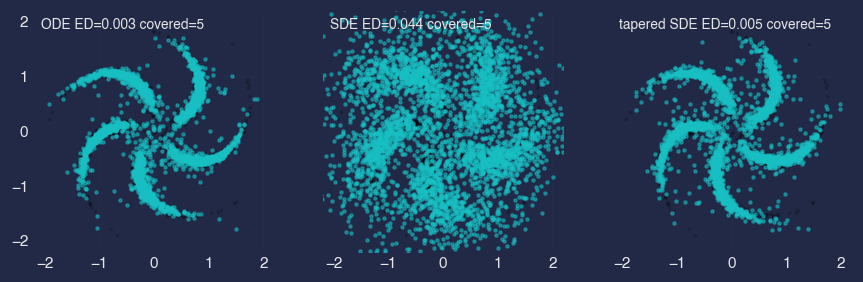

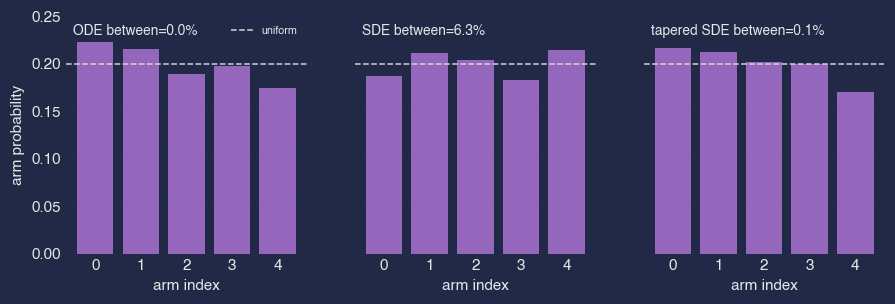

In [22]:
print("training on pinwheel ...")
pin_runs = {
    "ODE": train(
        sample_fn=sample_pinwheel, interpolant=nami.LinearInterpolant(), diffusion="none",
        steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
    "SDE": train(
        sample_fn=sample_pinwheel, interpolant=nami.BrownianBridgeInterpolant(sigma=1.0),
        diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
    "tapered SDE": train(
        sample_fn=sample_pinwheel, interpolant=TaperedBridgeInterpolant(sigma_max=0.3, p=2.0),
        diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
    ),
}

pin_eval, pin_eval_b = sample_pair(sample_pinwheel, seeds=(321, 322))
pin_baseline = {"ed": energy_distance(pin_eval, pin_eval_b), **pinwheel_stats(pin_eval)}
pin_samples, pin_metrics = evaluate_runs(pin_runs, pin_eval, stats_fn=pinwheel_stats, n=4000, steps=100, seed=7)

print()
print_metric_table(pin_metrics, baseline=pin_baseline, count_name="arms")

plot_sample_grid(pin_samples, reference=pin_eval, metrics=pin_metrics, xlim=(-2.2, 2.2), ylim=(-2.2, 2.2))
plot_mass_bars(pin_metrics, n_groups=N_ARMS, xlabel="arm index", ylabel="arm probability")


## Higher dimensions

In 2D the ODE either wins outright or stays close. The common argument for SDEs is strongest in higher-dimensional data, where stochastic exploration can offset accumulated solver error. Here we keep the intrinsic structure fixed: eight clusters on a sphere, with ambient dimension `D` in `{2, 8, 32}`.


In [23]:
def make_d_modes(dim: int, k: int = 8, radius: float = 3.0, seed: int = 0):
    if dim == 2:
        ang = torch.tensor([2 * math.pi * i / k for i in range(k)])
        return radius * torch.stack([torch.cos(ang), torch.sin(ang)], dim=-1)
    g = torch.Generator().manual_seed(seed)
    centers = torch.randn(k, dim, generator=g)
    return centers / centers.norm(dim=-1, keepdim=True) * radius


def sample_d_ring(centers: torch.Tensor, n: int, std: float = 0.15) -> torch.Tensor:
    k, dim = centers.shape
    idx = torch.randint(0, k, (n,))
    return centers[idx] + std * torch.randn(n, dim)


def d_mode_stats(samples, centers, threshold_frac: float = 0.3):
    k = centers.shape[0]
    dists = torch.cdist(samples, centers)
    nearest_d, nearest_i = dists.min(dim=-1)
    pairwise = torch.cdist(centers, centers)
    pairwise.fill_diagonal_(float("inf"))
    cutoff = threshold_frac * float(pairwise.min().item())
    on_mode = nearest_d < cutoff
    counts = torch.bincount(nearest_i[on_mode], minlength=k).float()
    p = counts / max(counts.sum().item(), 1.0)
    uniform = torch.full_like(p, 1.0 / k)
    eps = 1e-12
    return {
        "p": p.numpy(),
        "covered": int((p > 0.01).sum().item()),
        "kl": float((p * (p.clamp(min=eps).log() - uniform.log())).sum().item()),
        "between_mass": float(1.0 - on_mode.float().mean().item()),
    }


In [24]:
dim_grid = [2, 8, 32]
d_runs: dict[int, dict] = {}
d_results: dict[int, dict] = {}

for dim in dim_grid:
    centers = make_d_modes(dim, k=8, radius=3.0, seed=0)
    sample_fn = lambda n, centers=centers: sample_d_ring(centers, n)
    min_gap = torch.cdist(centers, centers).fill_diagonal_(float("inf")).min().item()
    print(f"D={dim}  min mode gap={min_gap:.3f}")

    runs_dim = {
        "ODE": train(
            dim=dim, sample_fn=sample_fn, interpolant=nami.LinearInterpolant(), diffusion="none",
            steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
        ),
        "SDE": train(
            dim=dim, sample_fn=sample_fn, interpolant=nami.BrownianBridgeInterpolant(sigma=1.0),
            diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
        ),
        "tapered SDE": train(
            dim=dim, sample_fn=sample_fn, interpolant=TaperedBridgeInterpolant(sigma_max=0.3, p=4.0),
            diffusion="diagonal", steps=TRAIN_STEPS, batch=TRAIN_BATCH, seed=0,
        ),
    }
    d_runs[dim] = {"centers": centers, **runs_dim}

    eval_a, eval_b = sample_pair(sample_fn, seeds=(101, 102))
    baseline_stats = d_mode_stats(eval_a, centers)
    res = {
        "baseline_ed": energy_distance(eval_a, eval_b),
        "baseline_kl": baseline_stats["kl"],
    }
    for label, run in runs_dim.items():
        sample = sample_from(run, n=4000, steps=100, seed=7)
        res[label] = {"ed": energy_distance(sample, eval_a), **d_mode_stats(sample, centers)}
    d_results[dim] = res

    baseline_row = {"ed": res["baseline_ed"], **baseline_stats}
    print_metric_table({label: res[label] for label in runs_dim}, baseline=baseline_row, count_name="modes")
    print()


D=2  min mode gap=2.296
run                              |      ED |  modes |       KL |  between
data baseline                    |  0.0009 |      8 |   0.0009 |    0.000
ODE                              |  0.0068 |      8 |   0.0017 |    0.006
SDE                              |  0.0242 |      8 |   0.0046 |    0.224
tapered SDE                      |  0.0159 |      8 |   0.0070 |    0.013

D=8  min mode gap=2.099
run                              |      ED |  modes |       KL |  between
data baseline                    |  0.0013 |      8 |   0.0008 |    0.022
ODE                              |  0.0040 |      8 |   0.0015 |    0.063
SDE                              |  0.0404 |      8 |   0.0755 |    0.947
tapered SDE                      |  0.0042 |      8 |   0.0017 |    0.089

D=32  min mode gap=3.531
run                              |      ED |  modes |       KL |  between
data baseline                    |  0.0016 |      8 |   0.0010 |    0.024
ODE                              |  0

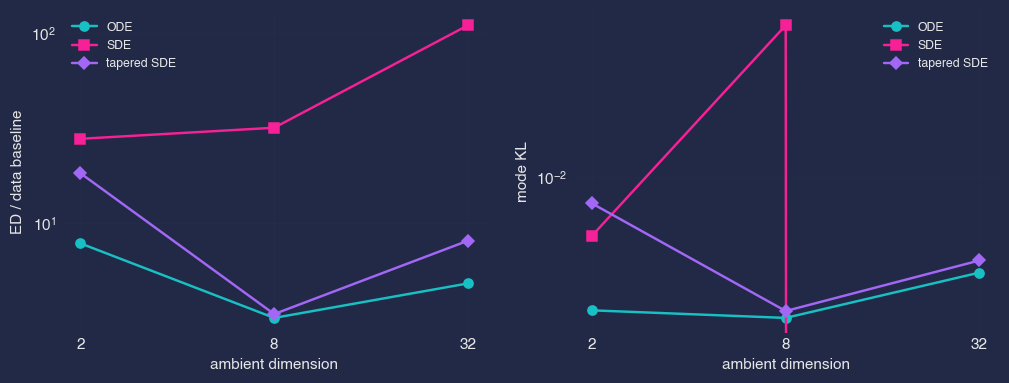


ED / baseline:
     D |                    ODE |                    SDE |            tapered SDE
     2 |                   7.81 |                  27.77 |                  18.29
     8 |                   3.16 |                  31.76 |                   3.31
    32 |                   4.80 |                 110.06 |                   8.06


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
labels_d = ["ODE", "SDE", "tapered SDE"]
markers = {"ODE": "o", "SDE": "s", "tapered SDE": "D"}

for label in labels_d:
    ax1.plot(
        dim_grid,
        [d_results[dim][label]["ed"] / d_results[dim]["baseline_ed"] for dim in dim_grid],
        marker=markers[label],
        lw=1.6,
        label=label,
    )
    ax2.plot(
        dim_grid,
        [d_results[dim][label]["kl"] for dim in dim_grid],
        marker=markers[label],
        lw=1.6,
        label=label,
    )

ax1.set_xscale("log", base=2)
ax1.set_xticks(dim_grid)
ax1.set_xticklabels(dim_grid)
ax1.set_xlabel("ambient dimension")
ax1.set_ylabel("ED / data baseline")
ax1.set_yscale("log")
ax1.legend(fontsize=8)

ax2.set_xscale("log", base=2)
ax2.set_xticks(dim_grid)
ax2.set_xticklabels(dim_grid)
ax2.set_xlabel("ambient dimension")
ax2.set_ylabel("mode KL")
ax2.set_yscale("log")
ax2.legend(fontsize=8)
plt.show()

print()
print("ED / baseline:")
print(f"  {'D':>4s} | " + " | ".join(f"{lab[:22]:>22s}" for lab in labels_d))
for dim in dim_grid:
    cells = " | ".join(f"{d_results[dim][lab]['ed'] / d_results[dim]['baseline_ed']:>22.2f}" for lab in labels_d)
    print(f"  {dim:>4d} | {cells}")


## Anisotropic noise

The diagonal generator can emit a separate diffusion coefficient per axis. The taper schedule is isotropic, but the learned field does not have to be. The last check visualises the pinwheel diffusion field and prints a simple anisotropy score.


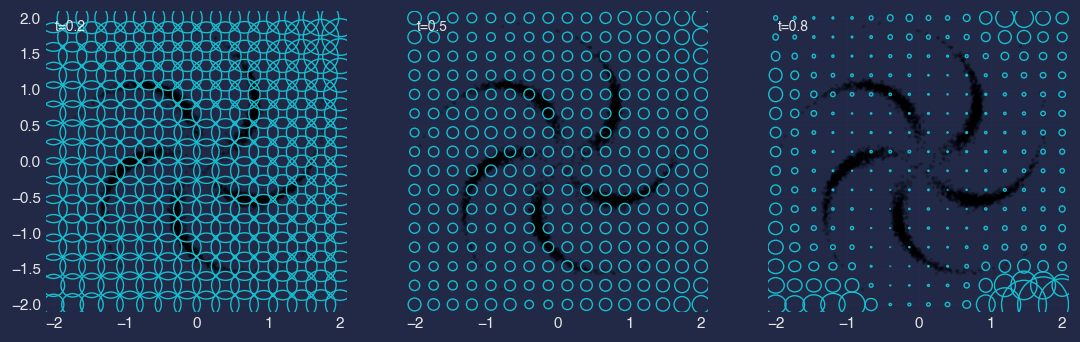

anisotropy score:
  SDE              : t=0.2: 0.000, t=0.5: 0.000, t=0.8: 0.000
  tapered SDE      : t=0.2: 0.001, t=0.5: 0.003, t=0.8: 0.028


In [26]:
from matplotlib.patches import Ellipse


@torch.no_grad()
def diffusion_grid(run, t: float, lim: float = 2.0, n: int = 18):
    op, field = run["op"], run["field"]
    xs = torch.linspace(-lim, lim, n)
    ys = torch.linspace(-lim, lim, n)
    gx, gy = torch.meshgrid(xs, ys, indexing="xy")
    pts = torch.stack([gx.flatten(), gy.flatten()], dim=-1)
    t_tensor = torch.full((pts.shape[0],), t)
    params = op.project(field(pts, t_tensor))
    diff = op.diffusion(pts, t_tensor, params).reshape(n, n, 2)
    return as_numpy(gx), as_numpy(gy), as_numpy(diff)


pin_run = pin_runs["tapered SDE"]
t_grid = [0.2, 0.5, 0.8]
fig, axes = plt.subplots(1, len(t_grid), figsize=(4.0 * len(t_grid), 4.2), sharex=True, sharey=True)
for ax, t in zip(axes, t_grid):
    scatter_points(ax, pin_eval, s=2, alpha=0.15, color="black")
    gx, gy, diff = diffusion_grid(pin_run, t=t, n=16)
    for i in range(gx.shape[0]):
        for j in range(gx.shape[1]):
            cx, cy = gx[i, j], gy[i, j]
            wx, wy = diff[i, j]
            ax.add_patch(
                Ellipse((cx, cy), width=2.0 * wx, height=2.0 * wy, angle=0,
                        facecolor="none", edgecolor="tab:cyan", lw=0.9)
            )
    panel_label(ax, f"t={t}")
    finish_equal(ax, xlim=(-2.1, 2.1), ylim=(-2.1, 2.1))
plt.show()


def anisotropy_score(run, t: float, lim: float = 2.0, n: int = 32):
    _, _, diff = diffusion_grid(run, t=t, lim=lim, n=n)
    g = diff.reshape(-1, 2)
    return float(np.abs(g[:, 0] - g[:, 1]).mean() / (g[:, 0] + g[:, 1]).mean())


print("anisotropy score:")
for label, run in pin_runs.items():
    if run["op"].diffusion_mode == "none":
        continue
    scores = {t: anisotropy_score(run, t) for t in [0.2, 0.5, 0.8]}
    line = "  " + label.ljust(16) + " : " + ", ".join(f"t={t}: {s:.3f}" for t, s in scores.items())
    print(line)
